In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="5" color="red"><b>ch3. 분류분석</b></font>

# 1절. 분류분석 개요
    - 데이터 속성을 활용하여, 데이터에 대한 분류기준을 수립하는 과정. 타겟변수가 categorical인 분석
        ex. 고객등급예측, 휴면고객예측, 상품구매예측, 보험사기자예측....
    - sklearn 패키지
    - pip install scikit-learn
## 라이브러리의 데이터 셋의 접근
### load계열(패키지안에 데이터가 내장)
    - load_iris(), load_boston()...

### fetch 계열(패키지에 데이터가 없고, 인터넷연결하여 다운로드)
    - fetch_covtype() : 토지조사 데이터
    - fetch_20newgroups() : 뉴스텍스트 말뭉치....

### make 계열(새로운 데이터 셋 생성)
    - make_classification() : 분류분석용 가상의 데이터 생성
    - make_regression() : 회귀분석용 가상의 데이터 생성

In [3]:
# load계열(패키지내에 데이터가 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# MNIST 데이터셋 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


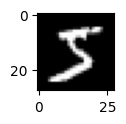

In [5]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [8]:
# fetch계열(인터넷 연결후 다운로드 c:/Users/내컴퓨터명/scikit_learn_data/openml/ 다운)
from sklearn.datasets import fetch_openml
import numpy as np
# MNIST 다운로드
mnist = fetch_openml(name='mnist_784',
                    version=1, # 데이터버전
                    as_frame=False, # False는 넘파이배열
                    parser='auto') # 파싱 방식을 sklearn이 자동결정

In [14]:
X, y = mnist.data, mnist.target.astype(np.uint8) # y는 1byte짜리 양수int
print('원 X, y :', X.shape, y.shape)
X = X.reshape(70000, 28,28)
print('reshape후 X, y :', X.shape, y.shape)

원 X, y : (70000, 784) (70000,)
reshape후 X, y : (70000, 28, 28) (70000,)


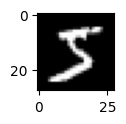

In [15]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X[0], cmap='gray')
plt.show()

# 2절. 분류분석의 종류
## 2.1 확률적 모형
- 주어진 데이터에 대해 각 클래스가 정답일 확률을 계산하는 모형
- **predict_proba() ; 각 분류 클래스가 될 확률들을 알려줌**(일부 판별함수모형에 있기는 함)
- **predict_log_proba() ; 확률의 로그값을 알려줌**

### 1) 확률적 생성모형
- 각 클래스별 특징 데이터의 확률분포를 추청한 다음 베이즈 정리를 사용하여 확률 계산. 소량의 데이터로도 작동하는 경우

### 2) 확률적 판별모형
- 확률 함수를 추정하는 모형. 성능이 좋고, 해석이 쉬움


## 2.2 판별함수 모형
- 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후, 이 경계면으로부터 데이터가 어느 위치에 있는 계산하는 판별함수를 이용하는 모형
- **decision_function() : 어떤 클래스로 분류되었다를 알려줌**